# KUIS KOMPUTASI STATISTIKA II

> Nama: Sahda Huwaidah Estiningtyas

> NIM: 24/545080/PA/23156

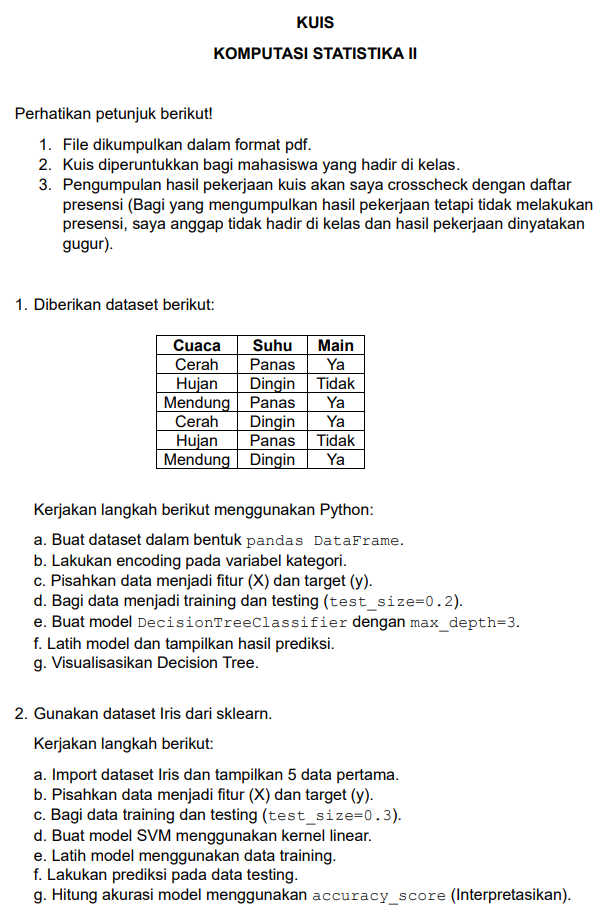

In [6]:
import os
from IPython.display import display, Image
import statsmodels.api as sm
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn import datasets
from sklearn.svm import SVC
import matplotlib.pyplot as plt

display(Image('kuis.png'))

Hasil Prediksi Decision Tree:
[0 1]


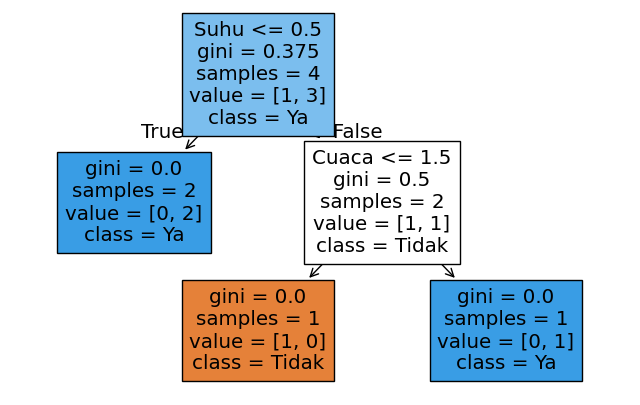

In [10]:
# 1. DECISION TREE
# a. Membuat DataFrame
data = {
    'Cuaca': ['Cerah', 'Hujan', 'Mendung', 'Cerah', 'Hujan', 'Mendung'],
    'Suhu': ['Panas', 'Dingin', 'Panas', 'Dingin', 'Panas', 'Dingin'],
    'Main': ['Ya', 'Tidak', 'Ya', 'Ya', 'Tidak', 'Ya']
}
df = pd.DataFrame(data)

# b. Encoding variabel kategori
encoder = LabelEncoder()

for kolom in df.columns:
    df[kolom] = encoder.fit_transform(df[kolom])

# c. Memisahkan fitur dan target
X = df[['Cuaca', 'Suhu']]
y = df['Main']

# d. Membagi data training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# e. Membuat model Decision Tree
model = DecisionTreeClassifier(max_depth=3)

# f. Melatih model dan prediksi
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Hasil Prediksi Decision Tree:")
print(y_pred)

# g. Visualisasi Decision Tree
plt.figure(figsize=(8,5))

plot_tree(
    model,
    feature_names=['Cuaca', 'Suhu'],
    class_names=['Tidak', 'Ya'],
    filled=True
)
plt.show()

## Interpretasi Decision Tree

a. Membuat dataset dalam bentuk pandas DataFrame
---------------------------------------------------------
Pada langkah ini, data cuaca, suhu, dan keputusan main dimasukkan ke dalam pandas DataFrame agar data dapat diolah menggunakan Python. DataFrame digunakan karena memiliki struktur tabel yang rapi seperti spreadsheet sehingga memudahkan proses analisis dan machine learning.


b. Melakukan encoding pada variabel kategori
---------------------------------------------------------
Karena algoritma Decision Tree pada sklearn hanya dapat memproses data numerik, maka data kategorikal seperti `Cerah`, `Hujan`, `Mendung`, `Panas`, `Dingin`, `Ya`, dan `Tidak` diubah menjadi bentuk angka menggunakan LabelEncoder.

Contohnya, `Ya` menjadi `1` dan `Tidak` menjadi `0`.
Tujuan encoding adalah agar komputer dapat membaca dan memproses data kategorikal.


c. Memisahkan data menjadi fitur (X) dan target (y)
---------------------------------------------------------
Fitur (X) berisi variabel input yang digunakan untuk prediksi, yaitu:
- `Cuaca`
- `Suhu`

Sedangkan target (y) adalah variabel hasil yang ingin diprediksi, yaitu:
- `Main`

Tujuan pemisahan ini adalah agar model dapat belajar hubungan antara fitur dan target.


d. Membagi data menjadi training dan testing (test_size=0.2)
---------------------------------------------------------
Dataset dibagi menjadi:
- 80% data training
- 20% data testing

Data training digunakan untuk melatih model Decision Tree, sedangkan data testing digunakan untuk menguji kemampuan model dalam melakukan prediksi pada data baru.

Parameter `test_size = 0.2` berarti 20% data digunakan sebagai data uji.


e. Membuat model DecisionTreeClassifier dengan max_depth=3
---------------------------------------------------------
Model Decision Tree dibuat menggunakan `DecisionTreeClassifier(max_depth=3)`

Parameter `max_depth=3` digunakan untuk membatasi kedalaman pohon keputusan agar model tidak terlalu kompleks dan mengurangi risiko overfitting.


f. Melatih model dan menampilkan hasil prediksi
---------------------------------------------------------
Model dilatih menggunakan data training, kemudian digunakan untuk memprediksi data testing.

Interpretasi:
- 0 merepresentasikan kelas "Tidak"
- 1 merepresentasikan kelas "Ya"

Hal ini menunjukkan bahwa model berhasil melakukan klasifikasi berdasarkan pola dari data training.


g. Visualisasi Decision Tree
---------------------------------------------------------
Visualisasi Decision Tree menunjukkan bagaimana model mengambil keputusan berdasarkan fitur.

Interpretasi visualisasi:
1. Root node pertama menggunakan fitur `Suhu <= 0.5`. Artinya model pertama kali memeriksa kondisi suhu.

2. Jika kondisi `TRUE`, maka langsung diprediksi kelas "Ya"

3. Jika kondisi `FALSE`, maka model memeriksa fitur berikutnya, yaitu `Cuaca <= 1.5`.

4. Berdasarkan hasil split tersebut, model menentukan kelas akhir `Tidak` dan `Ya`.

Informasi pada node:
- gini: menunjukkan tingkat impurity/ketidakmurnian data.
  Semakin kecil nilai gini, semakin homogen data.

- samples: jumlah data pada node tersebut.

- value: distribusi jumlah kelas.

- class: hasil prediksi mayoritas pada node tersebut.

Visualisasi ini membuktikan bahwa Decision Tree bekerja dengan aturan bercabang seperti proses pengambilan keputusan manusia.




In [8]:
# 2. SVM - IRIS DATASET
# a. Import dataset Iris
iris = datasets.load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['target'] = iris.target

print("a. 5 Data Pertama Iris Dataset:")
print(df_iris.head())

# b. Memisahkan fitur dan target
X = iris.data
y = iris.target

# c. Membagi data training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# d. Membuat model SVM kernel linear
svm_model = SVC(kernel='linear')

# e. Melatih model
svm_model.fit(X_train, y_train)

# f. Prediksi data testing
y_pred = svm_model.predict(X_test)

print("\n f. Hasil Prediksi SVM:")
print(y_pred)

# g. Menghitung akurasi
akurasi = accuracy_score(y_test, y_pred)
print("\n g. Akurasi Model SVM:", akurasi)

a. 5 Data Pertama Iris Dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

 f. Hasil Prediksi SVM:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0]

 g. Akurasi Model SVM: 1.0


## Interpretasi SVM

a. Import dataset Iris dan menampilkan 5 data pertama
---------------------------------------------------------
Dataset Iris diambil dari sklearn dan berisi data bunga iris dengan beberapa fitur:
- sepal length
- sepal width
- petal length
- petal width

Output 5 data pertama menunjukkan isi dataset berhasil dimuat.

Contoh:
5.1  3.5  1.4  0.2

Artinya:
- panjang sepal = 5.1 cm
- lebar sepal = 3.5 cm
- panjang petal = 1.4 cm
- lebar petal = 0.2 cm

b. Memisahkan data menjadi fitur (X) dan target (y)
---------------------------------------------------------
Fitur (X): seluruh atribut ukuran bunga

Target (y): kelas bunga iris

Tujuan langkah ini adalah agar model SVM dapat mempelajari hubungan antara ukuran bunga dan jenis bunga.


c. Membagi data training dan testing (test_size=0.3)
---------------------------------------------------------
Dataset dibagi menjadi:
- 70% data training
- 30% data testing

Data training digunakan untuk melatih model SVM, sedangkan data testing digunakan untuk evaluasi performa model.


d. Membuat model SVM menggunakan kernel linear
---------------------------------------------------------
Model dibuat menggunakan `SVC(kernel='linear')`

Kernel linear digunakan karena data dianggap dapat dipisahkan secara linear menggunakan hyperplane. Tujuan SVM adalah mencari hyperplane terbaik yang memiliki margin maksimum antar kelas.


e. Melatih model menggunakan data training
---------------------------------------------------------
Model SVM dilatih menggunakan data training agar dapat menemukan pola pemisah antar kelas bunga iris.
Pada proses ini, model menentukan support vector dan hyperplane optimal.


f. Melakukan prediksi pada data testing
---------------------------------------------------------
Output prediksi berupa `[1 0 2 1 1 0 1 2 ...]` menunjukkan hasil klasifikasi model terhadap data testing.

Interpretasi:
- 0 = kelas iris setosa
- 1 = kelas iris versicolor
- 2 = kelas iris virginica



g. Menghitung akurasi model menggunakan accuracy_score
---------------------------------------------------------

Berdasarkan output, nilai akurasi model adalah 1.0. Artinya, model memiliki akurasi 100% sehingga seluruh data testing berhasil diprediksi dengan benar oleh model SVM.

**Kesimpulan:**

Model SVM dengan kernel linear memiliki performa sangat baik pada dataset Iris karena mampu memisahkan kelas data secara sempurna menggunakan hyperplane optimal.